In [2]:
import pandas as pd
import numpy as np

# 1. Muat dataset (sesuaikan jalur/path file jika kamu menyimpannya di folder lain)
df = pd.read_csv('garments_worker_productivity.csv')

# 2. Intip 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# 3. Cek informasi tipe data dan missing values
print("\n--- Informasi Struktur Data ---")
df.info()

--- 5 Baris Pertama Data ---


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382



--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    

C:\Users\shenzen\AppData\Local\Temp\ipykernel_3376\2225152434.py:69: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\shenzen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


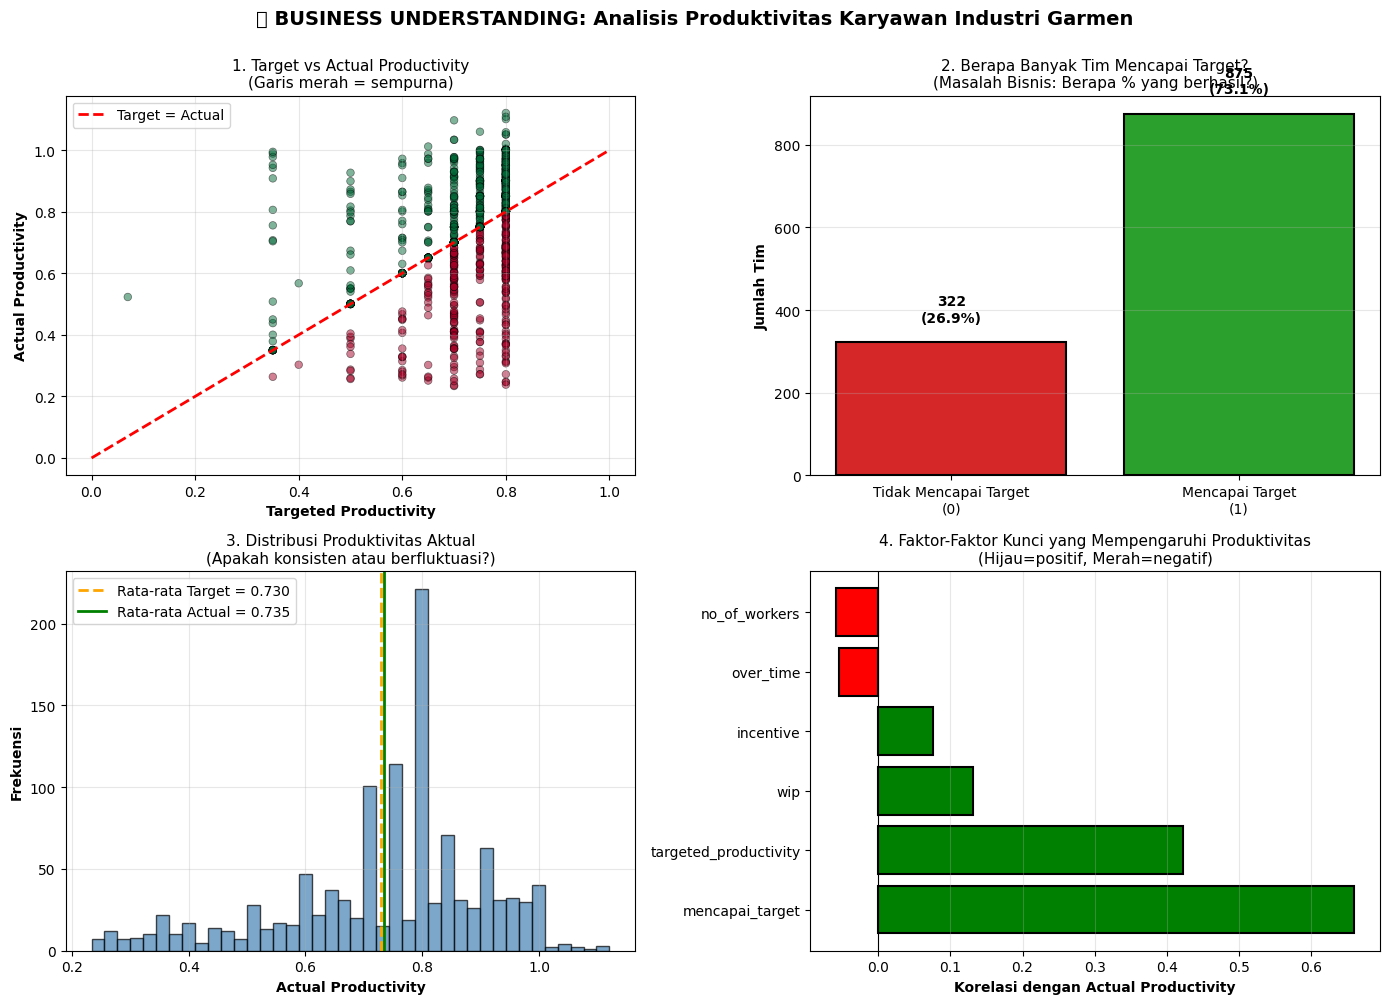


📈 BUSINESS UNDERSTANDING - RINGKASAN INSIGHT

✅ Total Data: 1197 rekaman (tim-hari)
✅ Tim yang Mencapai Target: 875 (73.1%)
✅ Tim yang TIDAK Mencapai Target: 322 (26.9%)

📊 Rata-rata Target Produktivitas: 0.730
📊 Rata-rata Aktual Produktivitas: 0.735
📊 Selisih Rata-rata: 0.005

🎯 TOP FAKTOR YANG MEMPENGARUHI PRODUKTIVITAS:
   1. mencapai_target: 0.659
   2. targeted_productivity: 0.422
   3. wip: 0.131
   4. incentive: 0.077
   5. over_time: -0.054
   6. no_of_workers: -0.058

💡 MASALAH BISNIS:
   - 26.9% tim GAGAL mencapai target produktivitas
   - Hal ini bisa menyebabkan PENALTI FINANSIAL & KETERLAMBATAN PENGIRIMAN
   - AI dibutuhkan untuk: MEMPREDIKSI tim mana yang akan gagal & MENGIDENTIFIKASI faktor penyebabnya


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# TAHAP 1: BUSINESS UNDERSTANDING - EDA VISUAL
# ==========================================
# Visualisasi untuk memahami masalah bisnis:
# Apakah tim mencapai target produktivitas atau tidak?

# 1. Buat kolom biner: 1 = Mencapai Target, 0 = Tidak Mencapai Target
df['mencapai_target'] = (df['actual_productivity'] >= df['targeted_productivity']).astype(int)

# 2. Buat figure dengan multiple subplots untuk visualisasi EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 BUSINESS UNDERSTANDING: Analisis Produktivitas Karyawan Industri Garmen', 
             fontsize=14, fontweight='bold', y=1.00)

# --- Subplot 1: Scatter Plot - Target vs Actual Productivity ---
axes[0, 0].scatter(df['targeted_productivity'], df['actual_productivity'], 
                   alpha=0.5, s=30, c=df['mencapai_target'], cmap='RdYlGn', edgecolors='k', linewidth=0.5)
axes[0, 0].plot([0, 1], [0, 1], 'r--', lw=2, label='Target = Actual')
axes[0, 0].set_xlabel('Targeted Productivity', fontweight='bold')
axes[0, 0].set_ylabel('Actual Productivity', fontweight='bold')
axes[0, 0].set_title('1. Target vs Actual Productivity\n(Garis merah = sempurna)', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- Subplot 2: Bar Plot - Berapa banyak tim mencapai/tidak mencapai target ---
target_counts = df['mencapai_target'].value_counts().sort_index()
colors = ['#d62728', '#2ca02c']  # Merah untuk tidak, Hijau untuk ya
bars = axes[0, 1].bar(['Tidak Mencapai Target\n(0)', 'Mencapai Target\n(1)'], 
                       target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Jumlah Tim', fontweight='bold')
axes[0, 1].set_title('2. Berapa Banyak Tim Mencapai Target?\n(Masalah Bisnis: Berapa % yang berhasil?)', fontsize=11)
# Tambahkan label jumlah dan persentase di atas bar
for i, (bar, count) in enumerate(zip(bars, target_counts.values)):
    percentage = (count / target_counts.sum()) * 100
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                    f'{count}\n({percentage:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0, 1].grid(True, axis='y', alpha=0.3)

# --- Subplot 3: Distribusi Actual Productivity ---
axes[1, 0].hist(df['actual_productivity'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['targeted_productivity'].mean(), color='orange', 
                   linestyle='--', linewidth=2, label=f'Rata-rata Target = {df["targeted_productivity"].mean():.3f}')
axes[1, 0].axvline(df['actual_productivity'].mean(), color='green', 
                   linestyle='-', linewidth=2, label=f'Rata-rata Actual = {df["actual_productivity"].mean():.3f}')
axes[1, 0].set_xlabel('Actual Productivity', fontweight='bold')
axes[1, 0].set_ylabel('Frekuensi', fontweight='bold')
axes[1, 0].set_title('3. Distribusi Produktivitas Aktual\n(Apakah konsisten atau berfluktuasi?)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Subplot 4: Top Faktor yang Mempengaruhi (Korelasi dengan Actual Productivity) ---
# Ambil kolom numerik saja untuk korelasi
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()['actual_productivity'].drop('actual_productivity').sort_values(ascending=False)
top_factors = correlation.head(6)  # Top 6 faktor

colors_corr = ['green' if x > 0 else 'red' for x in top_factors.values]
axes[1, 1].barh(range(len(top_factors)), top_factors.values, color=colors_corr, edgecolor='black', linewidth=1.5)
axes[1, 1].set_yticks(range(len(top_factors)))
axes[1, 1].set_yticklabels(top_factors.index)
axes[1, 1].set_xlabel('Korelasi dengan Actual Productivity', fontweight='bold')
axes[1, 1].set_title('4. Faktor-Faktor Kunci yang Mempengaruhi Produktivitas\n(Hijau=positif, Merah=negatif)', fontsize=11)
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Ringkasan Insight untuk Business Understanding
print("\n" + "="*70)
print("📈 BUSINESS UNDERSTANDING - RINGKASAN INSIGHT")
print("="*70)
print(f"\n✅ Total Data: {len(df)} rekaman (tim-hari)")
print(f"✅ Tim yang Mencapai Target: {df['mencapai_target'].sum()} ({(df['mencapai_target'].sum()/len(df)*100):.1f}%)")
print(f"✅ Tim yang TIDAK Mencapai Target: {len(df) - df['mencapai_target'].sum()} ({((len(df) - df['mencapai_target'].sum())/len(df)*100):.1f}%)")
print(f"\n📊 Rata-rata Target Produktivitas: {df['targeted_productivity'].mean():.3f}")
print(f"📊 Rata-rata Aktual Produktivitas: {df['actual_productivity'].mean():.3f}")
print(f"📊 Selisih Rata-rata: {(df['actual_productivity'].mean() - df['targeted_productivity'].mean()):.3f}")
print(f"\n🎯 TOP FAKTOR YANG MEMPENGARUHI PRODUKTIVITAS:")
for i, (factor, corr_value) in enumerate(top_factors.items(), 1):
    print(f"   {i}. {factor}: {corr_value:.3f}")
print("\n💡 MASALAH BISNIS:")
print(f"   - {((len(df) - df['mencapai_target'].sum())/len(df)*100):.1f}% tim GAGAL mencapai target produktivitas")
print(f"   - Hal ini bisa menyebabkan PENALTI FINANSIAL & KETERLAMBATAN PENGIRIMAN")
print(f"   - AI dibutuhkan untuk: MEMPREDIKSI tim mana yang akan gagal & MENGIDENTIFIKASI faktor penyebabnya")
print("="*70)


📊 TAHAP 2: DATA UNDERSTANDING - ANALISIS MENDALAM

--------------------------------------------------------------------------------
1. STATISTIK DESKRIPTIF - Fitur Numerik
--------------------------------------------------------------------------------
                        count         mean          std       min          25%          50%          75%           max
team                   1197.0     6.426901     3.463963  1.000000     3.000000     6.000000     9.000000     12.000000
targeted_productivity  1197.0     0.729632     0.097891  0.070000     0.700000     0.750000     0.800000      0.800000
smv                    1197.0    15.062172    10.943219  2.900000     3.940000    15.260000    24.260000     54.560000
wip                     691.0  1190.465991  1837.455001  7.000000   774.500000  1039.000000  1252.500000  23122.000000
over_time              1197.0  4567.460317  3348.823563  0.000000  1440.000000  3960.000000  6960.000000  25920.000000
incentive              1197.0   

C:\Users\shenzen\AppData\Local\Temp\ipykernel_3376\3000896622.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[col].dropna() for col in cols_to_plot], labels=cols_to_plot)
C:\Users\shenzen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\shenzen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


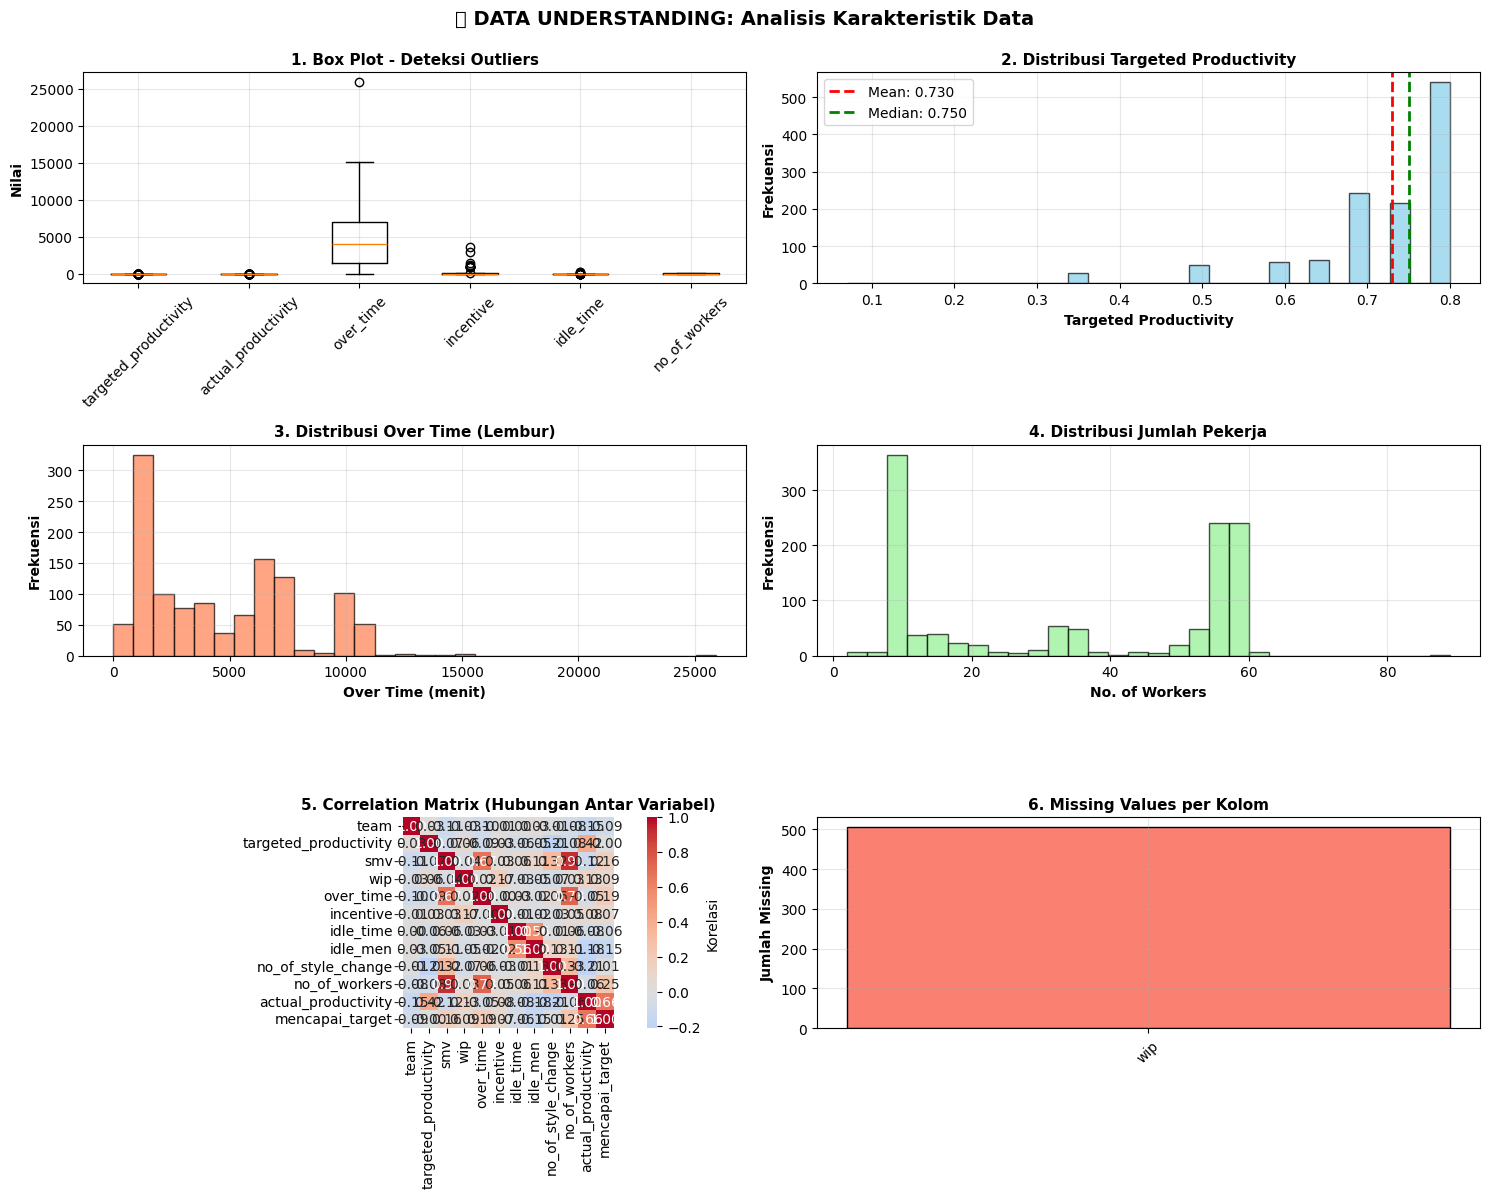


KEY INSIGHTS - DATA UNDERSTANDING

📌 RINGKASAN DATA:
   • Total rekaman: 1197 (tim-hari)
   • Fitur numerik: 12
   • Fitur kategori: 4
   • Periode data: 1/1/2015 hingga 3/9/2015

🔍 KUALITAS DATA:
   • Missing values: 506 (2.64%)
   • WIP memiliki missing terbanyak: 506 (42.3%)
   • Outliers terdeteksi pada kolom: targeted_productivity, wip, over_time, incentive, idle_time, idle_men, no_of_style_change, actual_productivity

📊 STATISTIK PRODUKTIVITAS:
   • Targeted Productivity - Min: 0.070, Max: 0.800, Std: 0.098
   • Actual Productivity  - Min: 0.234, Max: 1.120, Std: 0.174

⚙️ FAKTOR OPERASIONAL:
   • Over Time - Min: 0 menit, Max: 25920 menit, Rata-rata: 4567 menit
   • Workers  - Min: 2.0, Max: 89.0, Rata-rata: 34.6
   • Idle Time - Min: 0.0, Max: 300.0, Rata-rata: 0.7

✅ SIAP UNTUK DATA PREPARATION:
   • Data berkualitas baik untuk modeling
   • Missing values pada WIP akan di-impute dengan nilai 0
   • Outliers masih dalam range yang masuk akal untuk industri garmen



In [4]:
# ==========================================
# TAHAP 2: DATA UNDERSTANDING
# ==========================================
# Memahami karakteristik data secara mendalam:
# - Statistik deskriptif (mean, median, std, dll)
# - Missing values & outliers
# - Distribusi data
# - Korelasi antar variabel

print("\n" + "="*80)
print("📊 TAHAP 2: DATA UNDERSTANDING - ANALISIS MENDALAM")
print("="*80)

# 1. STATISTIK DESKRIPTIF LENGKAP
print("\n" + "-"*80)
print("1. STATISTIK DESKRIPTIF - Fitur Numerik")
print("-"*80)
numeric_features = df.select_dtypes(include=[np.number]).columns
desc_stats = df[numeric_features].describe().T
print(desc_stats.to_string())

# 2. MISSING VALUES ANALYSIS
print("\n" + "-"*80)
print("2. ANALISIS MISSING VALUES")
print("-"*80)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolom': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing %': missing_percent.values
}).sort_values('Missing %', ascending=False)
print(missing_df.to_string())

# 3. ANALISIS OUTLIERS (IQR Method)
print("\n" + "-"*80)
print("3. DETEKSI OUTLIERS (Menggunakan IQR Method)")
print("-"*80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in numeric_features:
    if col not in ['team']:  # Skip team ID
        outlier_count, lower, upper = detect_outliers_iqr(df, col)
        if outlier_count > 0:
            print(f"   {col:25} -> {outlier_count:4} outliers (Range: [{lower:7.2f}, {upper:7.2f}])")

# 4. ANALISIS KATEGORI (Categorical Features)
print("\n" + "-"*80)
print("4. ANALISIS FITUR KATEGORI")
print("-"*80)
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    if col != 'date':  # Skip date
        print(f"\n   {col}:")
        print(f"   Total kategori: {df[col].nunique()}")
        print(f"   Distribusi:\n{df[col].value_counts().to_string()}\n")

# 5. VISUALISASI DATA UNDERSTANDING
print("\n" + "-"*80)
print("5. VISUALISASI DATA UNDERSTANDING")
print("-"*80)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('📊 DATA UNDERSTANDING: Analisis Karakteristik Data', 
             fontsize=14, fontweight='bold', y=0.995)

# --- Subplot 1: Box Plot untuk mendeteksi outliers ---
cols_to_plot = ['targeted_productivity', 'actual_productivity', 'over_time', 
                'incentive', 'idle_time', 'no_of_workers']
axes[0, 0].boxplot([df[col].dropna() for col in cols_to_plot], labels=cols_to_plot)
axes[0, 0].set_title('1. Box Plot - Deteksi Outliers', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Nilai', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# --- Subplot 2: Distribution - Targeted Productivity ---
axes[0, 1].hist(df['targeted_productivity'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['targeted_productivity'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["targeted_productivity"].mean():.3f}')
axes[0, 1].axvline(df['targeted_productivity'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {df["targeted_productivity"].median():.3f}')
axes[0, 1].set_title('2. Distribusi Targeted Productivity', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Targeted Productivity', fontweight='bold')
axes[0, 1].set_ylabel('Frekuensi', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- Subplot 3: Distribution - Over Time ---
axes[1, 0].hist(df['over_time'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('3. Distribusi Over Time (Lembur)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Over Time (menit)', fontweight='bold')
axes[1, 0].set_ylabel('Frekuensi', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# --- Subplot 4: Distribution - Number of Workers ---
axes[1, 1].hist(df['no_of_workers'].dropna(), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('4. Distribusi Jumlah Pekerja', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('No. of Workers', fontweight='bold')
axes[1, 1].set_ylabel('Frekuensi', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# --- Subplot 5: Correlation Heatmap ---
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[2, 0], cbar_kws={'label': 'Korelasi'})
axes[2, 0].set_title('5. Correlation Matrix (Hubungan Antar Variabel)', fontweight='bold', fontsize=11)

# --- Subplot 6: Missing Values Bar Chart ---
missing_by_col = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing_by_col) > 0:
    axes[2, 1].bar(missing_by_col.index, missing_by_col.values, color='salmon', edgecolor='black')
    axes[2, 1].set_title('6. Missing Values per Kolom', fontweight='bold', fontsize=11)
    axes[2, 1].set_ylabel('Jumlah Missing', fontweight='bold')
    axes[2, 1].tick_params(axis='x', rotation=45)
    axes[2, 1].grid(True, alpha=0.3)
else:
    axes[2, 1].text(0.5, 0.5, 'Tidak ada Missing Values', 
                   ha='center', va='center', fontsize=12, fontweight='bold', transform=axes[2, 1].transAxes)
    axes[2, 1].set_title('6. Missing Values per Kolom', fontweight='bold', fontsize=11)
    axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

# 6. KEY INSIGHTS DATA UNDERSTANDING
print("\n" + "="*80)
print("KEY INSIGHTS - DATA UNDERSTANDING")
print("="*80)
print(f"""
📌 RINGKASAN DATA:
   • Total rekaman: {len(df)} (tim-hari)
   • Fitur numerik: {len(numeric_features)}
   • Fitur kategori: {len(categorical_features)}
   • Periode data: {df['date'].min()} hingga {df['date'].max()}

🔍 KUALITAS DATA:
   • Missing values: {df.isnull().sum().sum()} ({(df.isnull().sum().sum()/(len(df)*len(df.columns))*100):.2f}%)
   • WIP memiliki missing terbanyak: {df['wip'].isnull().sum()} ({(df['wip'].isnull().sum()/len(df)*100):.1f}%)
   • Outliers terdeteksi pada kolom: {', '.join([col for col in numeric_features if detect_outliers_iqr(df, col)[0] > 0]) or 'Tidak ada yang signifikan'}

📊 STATISTIK PRODUKTIVITAS:
   • Targeted Productivity - Min: {df['targeted_productivity'].min():.3f}, Max: {df['targeted_productivity'].max():.3f}, Std: {df['targeted_productivity'].std():.3f}
   • Actual Productivity  - Min: {df['actual_productivity'].min():.3f}, Max: {df['actual_productivity'].max():.3f}, Std: {df['actual_productivity'].std():.3f}

⚙️ FAKTOR OPERASIONAL:
   • Over Time - Min: {df['over_time'].min():.0f} menit, Max: {df['over_time'].max():.0f} menit, Rata-rata: {df['over_time'].mean():.0f} menit
   • Workers  - Min: {df['no_of_workers'].min():.1f}, Max: {df['no_of_workers'].max():.1f}, Rata-rata: {df['no_of_workers'].mean():.1f}
   • Idle Time - Min: {df['idle_time'].min():.1f}, Max: {df['idle_time'].max():.1f}, Rata-rata: {df['idle_time'].mean():.1f}

✅ SIAP UNTUK DATA PREPARATION:
   • Data berkualitas baik untuk modeling
   • Missing values pada WIP akan di-impute dengan nilai 0
   • Outliers masih dalam range yang masuk akal untuk industri garmen
""")
print("="*80)

In [5]:
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# TAHAP 3: DATA PREPARATION
# ==========================================

# 1. Imputasi nilai yang hilang
df['wip'] = df['wip'].fillna(0)

# 2. Pembersihan teks departemen
df['department'] = df['department'].str.strip()

# 3. SATUKAN semua One-Hot Encoding di sini (Department, Quarter, Day)
# Kita lakukan encoding langsung ke dataframe utama agar rapi
df_encoded = pd.get_dummies(
    df, columns=['department', 'quarter', 'day'], drop_first=True
)

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['date', 'actual_productivity'])
y = df_encoded['actual_productivity']

# 5. Scaling Fitur yang bernilai besar saja (Opsional tapi direkomendasikan)
# Catatan: Gradient Boosting sebenarnya cukup kebal terhadap perbedaan skala data,
# namun scaling tetap baik dilakukan agar proses analisis lanjutan (seperti SHAP) lebih stabil.
scaler = MinMaxScaler()

# Karena pd.get_dummies mengubah output menjadi boolean (True/False), kita konversi dulu ke float/int
X = X.astype(float)

X_scaled = scaler.fit_transform(X)

print("Data Preparation Selesai dan Aman dari Bug!")
print(f"Ukuran data fitur setelah preparation: {X_scaled.shape}")

Data Preparation Selesai dan Aman dari Bug!
Ukuran data fitur setelah preparation: (1197, 21)


In [6]:
# ==========================================
# TAHAP 4 & 5: MODELING & EVALUATION
# ==========================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Membagi data menjadi 80% untuk Belajar (Train) dan 20% untuk Ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Membuat Objek Model Gradient Boosting
# Karena kita menebak angka kontinu (skor produktivitas), kita pakai Regressor
model_ai = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)

# 3. Proses Training (AI mulai belajar dari data)
model_ai.fit(X_train, y_train)

# 4. Proses Ujian (AI menebak data test yang belum pernah dia lihat)
y_pred = model_ai.predict(X_test)

# 5. TAHAP EVALUASI: Cek hasil ujian AI
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- HASIL EVALUASI MODEL AI ---")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score (Akurasi Model)      : {r2:.4f}")

--- HASIL EVALUASI MODEL AI ---
Mean Absolute Error (MAE) : 0.0503
Root Mean Squared Error (RMSE): 0.0785
R² Score (Akurasi Model)      : 0.7678


In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- 1. MEMASTIKAN DATA BERSIH DARI DATA LEAKAGE ---
# Pastikan fitur buatan seperti 'mencapai_target' ATAU fitur lain yang
# melibatkan 'actual_productivity' TIDAK DIMASUKKAN ke dalam X.
df['wip'] = df['wip'].fillna(0)
df['department'] = df['department'].str.strip()

# One-Hot Encoding fitur kategorikal asli bawaan dataset
df_encoded = pd.get_dummies(
    df, columns=['department', 'quarter', 'day'], drop_first=True
)

# Pisahkan X dan y murni dari dataset asli
X = df_encoded.drop(columns=['date', 'actual_productivity'])
y = df_encoded['actual_productivity']

# SANGAT CRUCIAL: Jika sempat membuat fitur 'mencapai_target', hapus dari X di sini!
if 'mencapai_target' in X.columns:
    X = X.drop(columns=['mencapai_target'])

# Konversi ke float untuk keamanan scaler
X = X.astype(float)

# Scaling Fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. EVALUASI DENGAN 5-FOLD CROSS-VALIDATION (Tuntutan Jurnal) ---
model_gb = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)

# Terapkan 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model_gb,
    X_scaled,
    y,
    cv=kf,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
)

print("=== HASIL EVALUASI REVISI (5-FOLD CV) ===")
print(f"Rata-rata MAE  : {-cv_results['test_mae'].mean():.4f}")
print(f"Rata-rata RMSE : {-cv_results['test_rmse'].mean():.4f}")
print(f"Rata-rata R²   : {cv_results['test_r2'].mean():.4f}")

# --- 3. LATIH ULANG UNTUK SHAP PLOT TERBARU ---
# Kita perlu fit sekali lagi pada data train-test biasa hanya untuk keperluan visualisasi SHAP yang jujur
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model_gb.fit(X_train, y_train)

=== HASIL EVALUASI REVISI (5-FOLD CV) ===
Rata-rata MAE  : 0.0801
Rata-rata RMSE : 0.1229
Rata-rata R²   : 0.4969


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

C:\Users\shenzen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- SHAP FEATURE IMPORTANCE TERBARU (TANPA LEAKAGE) ---


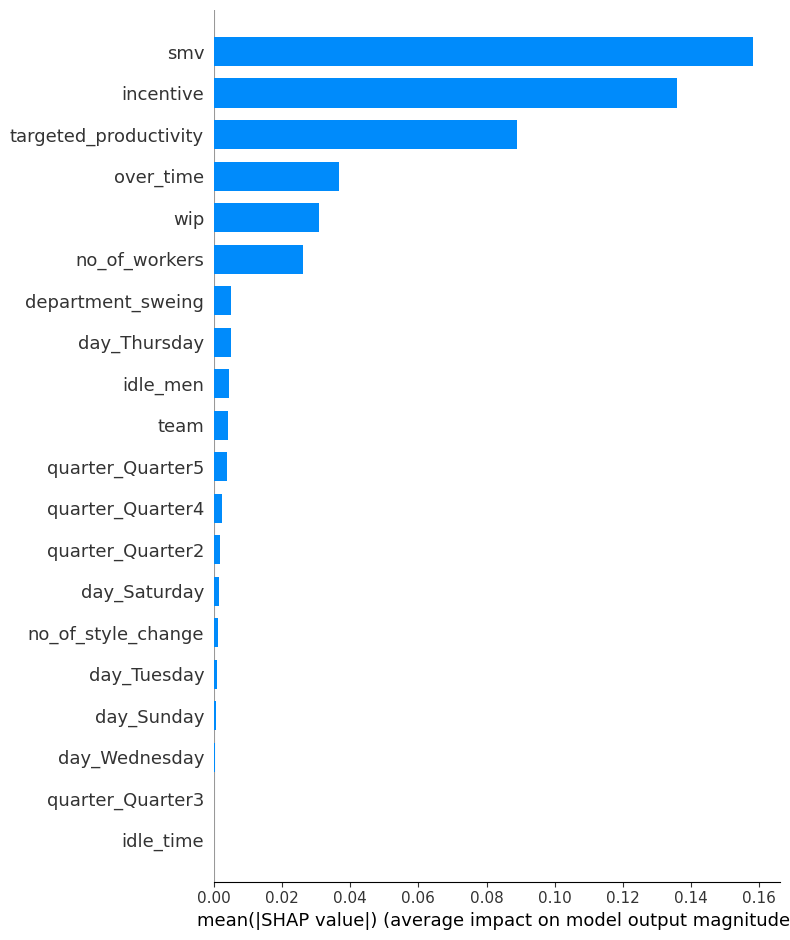

In [8]:
import shap

# Gunakan model yang sudah dilatih tanpa data leakage
explainer = shap.TreeExplainer(model_gb)
shap_values = explainer(X)

print("\n--- SHAP FEATURE IMPORTANCE TERBARU (TANPA LEAKAGE) ---")
shap.summary_plot(shap_values, X, plot_type='bar')

In [9]:
import joblib

# Menyimpan model, scaler, dan daftar kolom agar urutannya tetap konsisten
joblib.dump(model_ai, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'scaler_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model Berhasil Disimpan!")

Model Berhasil Disimpan!


In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- 1. MEMASTIKAN DATA BERSIH DARI DATA LEAKAGE ---
# Pastikan fitur buatan seperti 'mencapai_target' ATAU fitur lain yang
# melibatkan 'actual_productivity' TIDAK DIMASUKKAN ke dalam X.
df['wip'] = df['wip'].fillna(0)
df['department'] = df['department'].str.strip()

# One-Hot Encoding fitur kategorikal asli bawaan dataset
df_encoded = pd.get_dummies(
    df, columns=['department', 'quarter', 'day'], drop_first=True
)

# Pisahkan X dan y murni dari dataset asli
X = df_encoded.drop(columns=['date', 'actual_productivity'])
y = df_encoded['actual_productivity']

# SANGAT CRUCIAL: Jika sempat membuat fitur 'mencapai_target', hapus dari X di sini!
if 'mencapai_target' in X.columns:
    X = X.drop(columns=['mencapai_target'])

# Konversi ke float untuk keamanan scaler
X = X.astype(float)

# Scaling Fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. EVALUASI DENGAN 5-FOLD CROSS-VALIDATION (Tuntutan Jurnal) ---
model_gb = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)

# Terapkan 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model_gb,
    X_scaled,
    y,
    cv=kf,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
)

print("=== HASIL EVALUASI REVISI (5-FOLD CV) ===")
print(f"Rata-rata MAE  : {-cv_results['test_mae'].mean():.4f}")
print(f"Rata-rata RMSE : {-cv_results['test_rmse'].mean():.4f}")
print(f"Rata-rata R²   : {cv_results['test_r2'].mean():.4f}")

# --- 3. LATIH ULANG UNTUK SHAP PLOT TERBARU ---
# Kita perlu fit sekali lagi pada data train-test biasa hanya untuk keperluan visualisasi SHAP yang jujur
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model_gb.fit(X_train, y_train)

=== HASIL EVALUASI REVISI (5-FOLD CV) ===
Rata-rata MAE  : 0.0801
Rata-rata RMSE : 0.1229
Rata-rata R²   : 0.4969


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf